In [50]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
FILE_PATH = Path.cwd().parent / "datasets" / "loan_data.csv" # Create FILE_PATH to dynamically load the data instead of relative paths.

In [3]:
df = pd.read_csv(FILE_PATH)

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Initial Hypothesis

> We are dealing with a classification problem on a loan database

    1.Target column is loan_status 
    2.We have to predict from other columns whether the person applying loan should be approved or not.
    3.Our Main goal is to create such a system which flags more people who should not be given loan and put a tighter constrain to approval
    4.In short our model must have a low FalsePositive value (FP)
    5.Baseline Model : LogisticRegression ; Ensemble Model : RandomForestClassifier

In [5]:
def pre_stage(df):
    print(f"Dataframe shape : {df.shape}")
    print("-"*100)
    print(f"Memory Usage : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("-"*100)
    print(f"Target column  : \n{df['loan_status'].value_counts()}")
    print("-"*100)
    print(f"Column Dtypes: \n{df.dtypes.value_counts()}")
    print("-"*100)
    if df.isna().sum().sum() != 0 : 
        print(f"# Missing rows : {df.isna().sum().sum()}")
        print(f"Cols with missing rows : \n{df.isna().sum().sort_values(ascending=True).head(10)}")
    else:
        print(f"No missing rows")

In [6]:
pre_stage(df)

Dataframe shape : (45000, 14)
----------------------------------------------------------------------------------------------------
Memory Usage : 14.97 MB
----------------------------------------------------------------------------------------------------
Target column  : 
loan_status
0    35000
1    10000
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Column Dtypes: 
float64    6
object     5
int64      3
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
No missing rows


In [7]:
# We can load the complete dataset as it is of near 15 MB in size.
# We can clearly see that there are 5 object cols we must deal with .
# Also the target column is imbalanced so we must keep this in mind and use stratify when doing train_test_Split so all 0's dont crowd in a subset.
# We also have a good news i.e : we have no missing rows to deal with.

## EDA ~ Surface Level

In [8]:
df.info() # Here we can look again at each cols ; their dtype and missing value count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [9]:
# Now let's look at the 5 number summary of current numeric values
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [10]:
""" 
person_age : 
    Here we can clearly see that max age value is 144 which is not possible 
    reccommended strategy : use min_age = 0 and max_age = 100 to remove values beyond this boundary
    (In practice we would use a industrial threshold given by the client like : 20-80)

person_emp_ep
    Again how can person have a exp of 125 years ?!!
    O is valid as a person can be inexperienced
    We will go with using a threshold of 80 for now as person_emp_exp's upper limit .

REST ALL COLS are okay for now

"""

" \nperson_age : \n    Here we can clearly see that max age value is 144 which is not possible \n    reccommended strategy : use min_age = 0 and max_age = 100 to remove values beyond this boundary\n    (In practice we would use a industrial threshold given by the client like : 20-80)\n\nperson_emp_ep\n    Again how can person have a exp of 125 years ?!!\n    O is valid as a person can be inexperienced\n    We will go with using a threshold of 80 for now as person_emp_exp's upper limit .\n\nREST ALL COLS are okay for now\n\n"

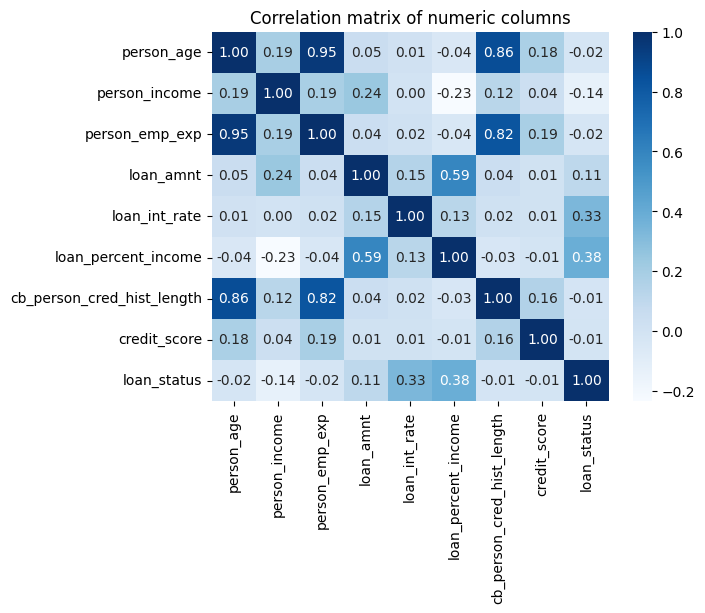

In [11]:
sns.heatmap(df.corr(numeric_only=True),cmap="Blues",annot=True,fmt='.2f')
plt.title("Correlation matrix of numeric columns")
plt.show()

In [12]:
""" 
person_emp_exp and person_age have a strong correlation 
    This will cause multicollinearity
cb_person_cred_hist_length
    This column is correlated really well with two other columns 
    Nor this column or the other two column correlate well with the loan_status
    We shall drop the column at the end durring splitting.
"""

' \nperson_emp_exp and person_age have a strong correlation \n    This will cause multicollinearity\ncb_person_cred_hist_length\n    This column is correlated really well with two other columns \n    Nor this column or the other two column correlate well with the loan_status\n    We shall drop the column at the end durring splitting.\n'

### THRESHOLDING : Removing redundant cols 

In [13]:
#n First the column age
age_upper_limit = 100
age_lower_limit = 0
df[(df["person_age"] > age_upper_limit) | (df["person_age"] < age_lower_limit )]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
37930,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.00,24.0,708,No,0
38113,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.00,22.0,792,No,0


In [14]:
# We drop these values as they are in few in numbers ( Not dropped but we selected such rows which satisfied this condition)
df = df[(df["person_age"] < age_upper_limit) & (df["person_age"] > age_lower_limit )]

In [15]:
# Now the person_emp_exp columns
exp_upper_limit = 80
exp_lower_limit = 0
df[(df["person_emp_exp"] > exp_upper_limit) | (df["person_emp_exp"] < exp_lower_limit )]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


In [16]:
# Why no rows returned you ask ?
""" 
    Look closely at the rows we dropped above for age , there already we dropped these cols unconsiouslly as well.
    It was 2 strikes with one arrow.So we now dont even need to drop any values 
"""

' \n    Look closely at the rows we dropped above for age , there already we dropped these cols unconsiouslly as well.\n    It was 2 strikes with one arrow.So we now dont even need to drop any values \n'

In [17]:
# Also keeping in mind : 
n_rows_dropped = 6
n_rows = len(df)
print(f"The percentage of rows lost : {(n_rows_dropped/n_rows)*100:.2f}%")
# This much data loss is negligible and infact better for our model 

The percentage of rows lost : 0.01%


## Mapping Strategy

First we examine the cols with object dtype and examine each's cardinality to look what to do next.

In [18]:
df.select_dtypes("object").head() # 5 Cols

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
0,female,Master,RENT,PERSONAL,No
1,female,High School,OWN,EDUCATION,Yes
2,female,High School,MORTGAGE,MEDICAL,No
3,female,Bachelor,RENT,MEDICAL,No
4,male,Master,RENT,MEDICAL,No


In [19]:
df.select_dtypes("object").nunique().sort_values(ascending=True) # The cardinality for each cols

person_gender                     2
previous_loan_defaults_on_file    2
person_home_ownership             4
person_education                  5
loan_intent                       6
dtype: int64

In [20]:
# Let's quickly peek into each unique column values and their value counts
for x in df.select_dtypes("object").nunique().sort_values(ascending=True).index:
    print(f'{df[x].value_counts()}\n')

person_gender
male      24836
female    20157
Name: count, dtype: int64

previous_loan_defaults_on_file
Yes    22856
No     22137
Name: count, dtype: int64

person_home_ownership
RENT        23440
MORTGAGE    18485
OWN          2951
OTHER         117
Name: count, dtype: int64

person_education
Bachelor       13396
Associate      12026
High School    11970
Master          6980
Doctorate        621
Name: count, dtype: int64

loan_intent
EDUCATION            9151
MEDICAL              8548
VENTURE              7815
PERSONAL             7551
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64



In [21]:
# Looks like a lump of text so open it in a text editor somwhere 

In [22]:
""" 
    There is almost no class imbalance in each cols except for some.
    But we should not do anything on those imbalanced cols as on examining found out that those cols should be less in count

    let cardinality be "c"

    for c = 2 : OrdinalEncoding is simplest and good for now ( or Mapping ) , since there is no heirarchical order also.
    for person_home_ownership : we will use OneHotEncoding as there is no heirarchy.
    for person_education :  we assign custom heirarchical levels based on education
    for loan_intent : again onc with drop first 

    # NOTE : We can switch to some other strategy for loan_intent or ownership as applying onc on many cols will cause sparsity.
"""

' \n    There is almost no class imbalance in each cols except for some.\n    But we should not do anything on those imbalanced cols as on examining found out that those cols should be less in count\n\n    let cardinality be "c"\n\n    for c = 2 : OrdinalEncoding is simplest and good for now ( or Mapping ) , since there is no heirarchical order also.\n    for person_home_ownership : we will use OneHotEncoding as there is no heirarchy.\n    for person_education :  we assign custom heirarchical levels based on education\n    for loan_intent : again onc with drop first \n\n    # NOTE : We can switch to some other strategy for loan_intent or ownership as applying onc on many cols will cause sparsity.\n'

In [23]:
df.select_dtypes("number").drop(columns=['loan_status'])

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586
...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604


## Splititng Data 

In [24]:
# We split beforehand applying any transformation , cause we do not want to cause any type of data leaks

In [25]:
X , y = df.drop(columns=['loan_status']) , df['loan_status']

In [26]:
# Also explicilty at this stage use the Label encoder on y class to make sure our y is seperately handled beforehand

lab = LabelEncoder()

lab.fit(y)
y_enc = lab.transform(y)

In [27]:
# Also split into training and testing set as well 
# This is because we will only use the training set to fit the encoders and then use the transform only for X_test
# This way we keep it clean
# And of course we wrap this complete process in a column transformer 
# Also we use a single Column transformer and not pipeline bundled into a column transformer as we have few steps only

In [28]:
X_train , X_test , y_train ,y_test = train_test_split(
                                                        X,y_enc,
                                                        stratify=y, # To make sure any split is overcrowded with y = majority_class
                                                        test_size = 0.2,
                                                        random_state=42
)

## Distribution Analysis ~ numeric columns

In [29]:
# We analyze the numeric cols now before pipelining 

In [33]:
X_train.select_dtypes("number").head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
35300,31.0,44485.0,4,8000.0,8.83,0.18,8.0,668
9746,24.0,35851.0,0,8725.0,12.18,0.24,2.0,645
26766,28.0,121251.0,6,25000.0,11.01,0.21,6.0,569
12944,23.0,76537.0,1,12000.0,14.96,0.16,4.0,538
466,24.0,53633.0,4,23975.0,11.01,0.45,2.0,678


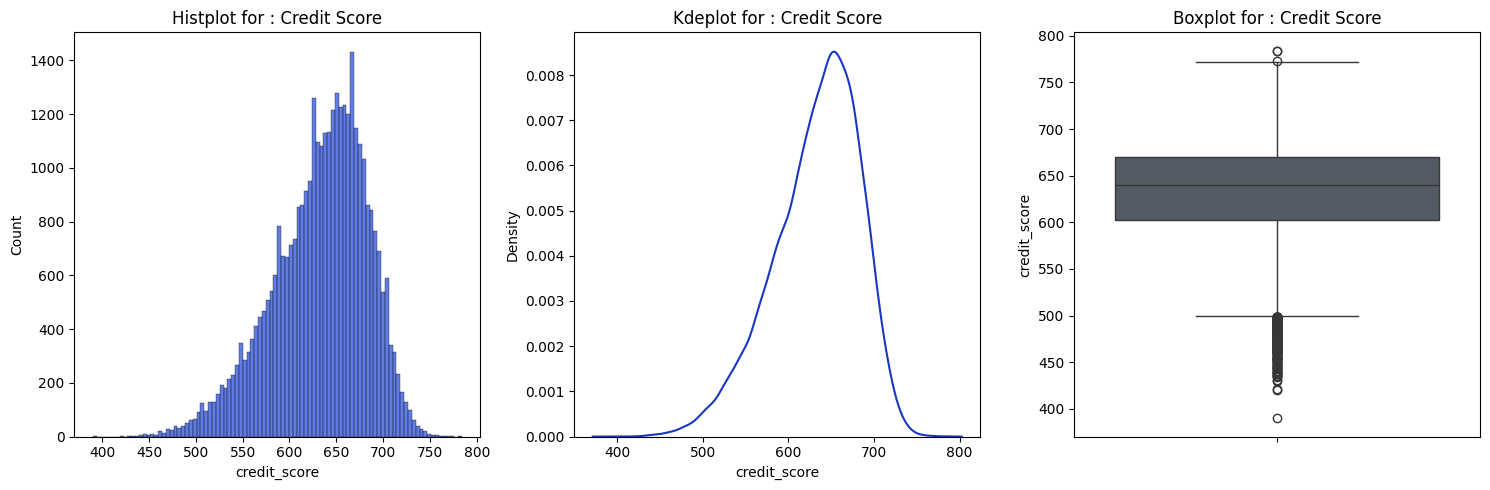

In [ ]:
# Credit score 

plt.figure(figsize=(15,5))

plt.subplot(131)
sns.histplot(data=X_train['credit_score'],color="#2C51D7F5")
plt.title("Histplot for : Credit Score")

plt.subplot(132)
sns.kdeplot(data=X_train['credit_score'],color="#1837C2")
plt.title("Kdeplot for : Credit Score")

plt.subplot(133)
sns.boxplot(data=X_train['credit_score'],color="#515B68")
plt.title("Boxplot for : Credit Score")

plt.tight_layout()
plt.show()

In [47]:
# The credit score distribution when looked is a bit left skewed but it can be handled.

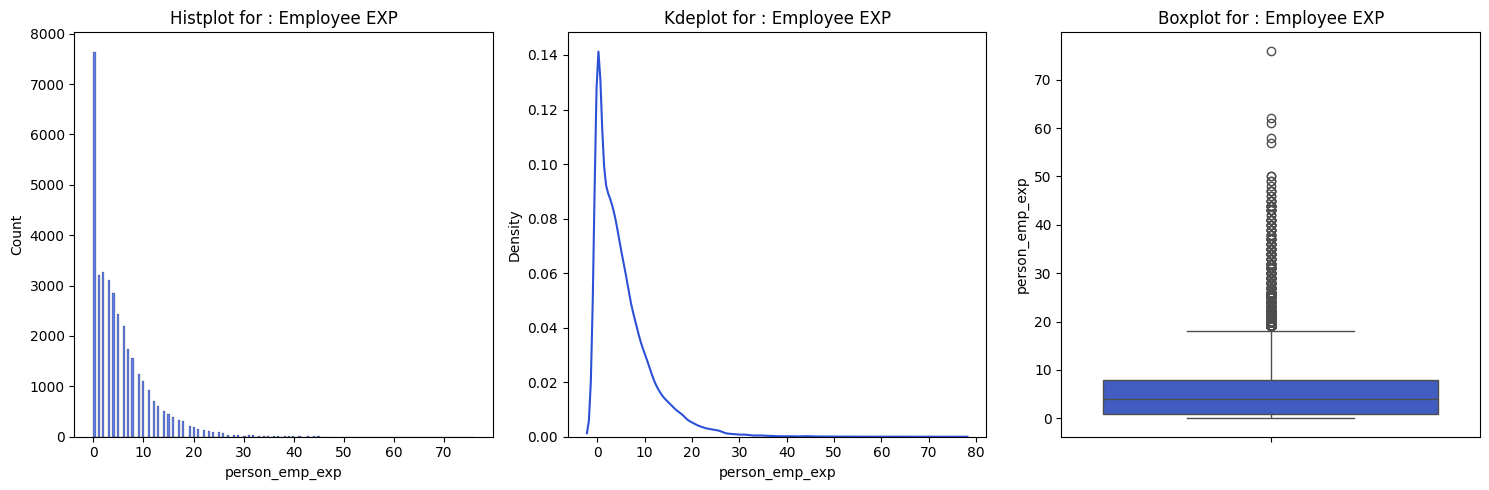

In [48]:
# Employee EXP

plt.figure(figsize=(15,5))

plt.subplot(131)
sns.histplot(data=X_train['person_emp_exp'],color="#2C51D7F5")
plt.title("Histplot for : Employee EXP")

plt.subplot(132)
sns.kdeplot(data=X_train['person_emp_exp'],color="#2C51D7F5")
plt.title("Kdeplot for : Employee EXP")

plt.subplot(133)
sns.boxplot(data=X_train['person_emp_exp'],color="#2C51D7F5")
plt.title("Boxplot for : Employee EXP")

plt.tight_layout()
plt.show()

In [49]:
# We can clearly see that there are a lot of people with 0 exp value 
# Let's fix this by trying different types of transformers on this distribution to  find the best fix

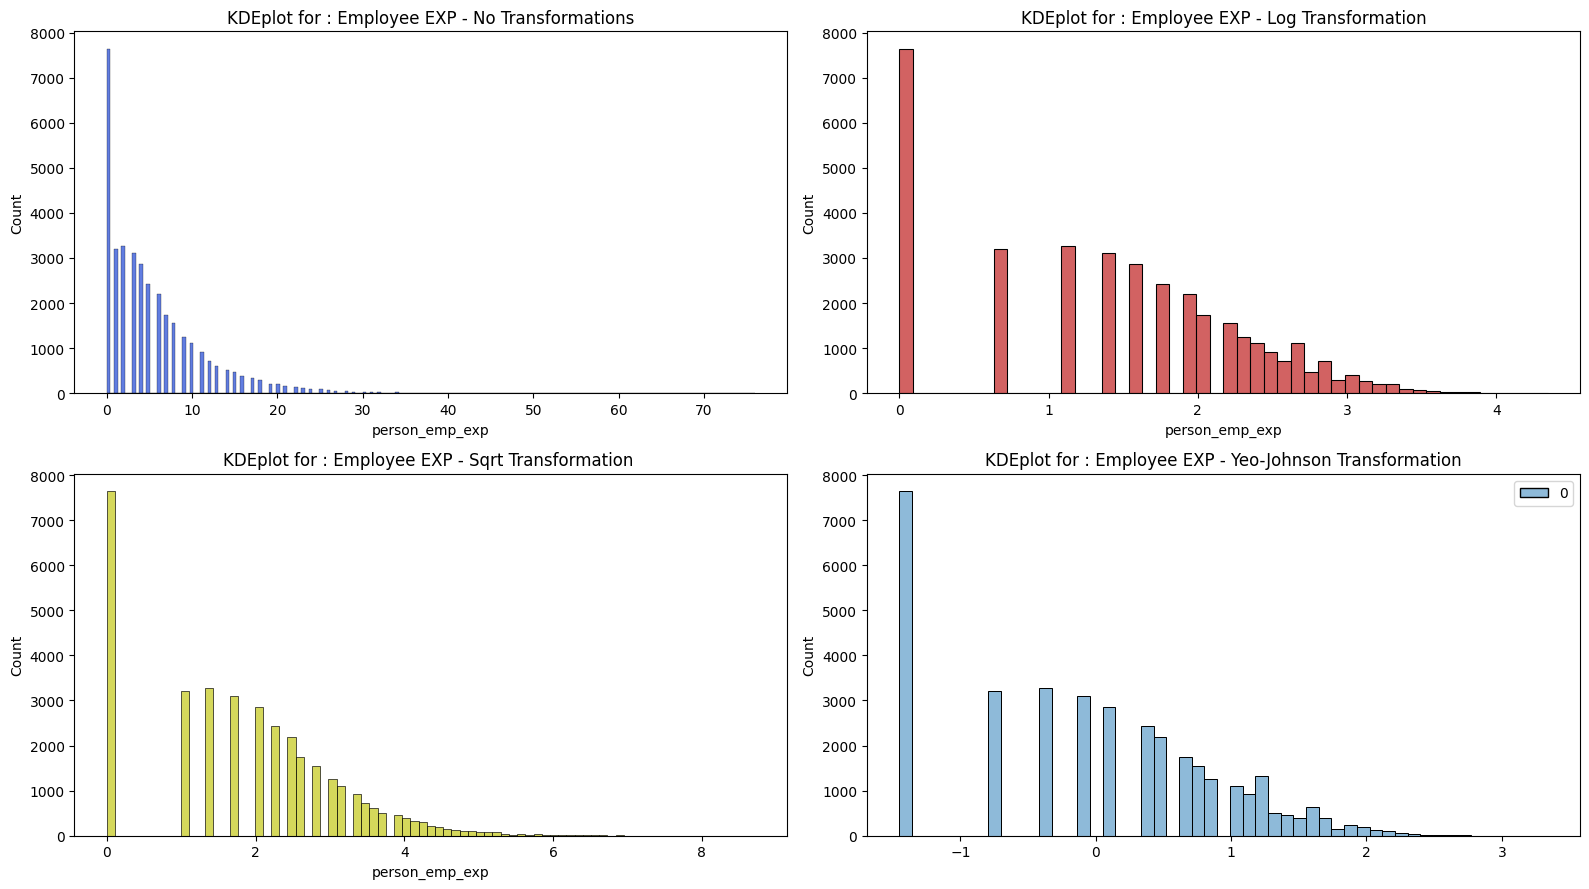

In [56]:
# Experimenting different transformation on Employee EXP


# Instantiate / Create custom transformers

def log_transformer(X):
    return np.log1p(X)

def sqrt_transformer(X):
    return np.sqrt(X)

yj = PowerTransformer(method='yeo-johnson')


# Plot on dynamic transformed column

plt.figure(figsize=(16,9))

plt.subplot(221)
sns.histplot(data=X_train['person_emp_exp'],color="#2C51D7F5")
plt.title("KDEplot for : Employee EXP - No Transformations")

plt.subplot(222)
sns.histplot(data=log_transformer(X_train['person_emp_exp']),color="#C32D2D")
plt.title("KDEplot for : Employee EXP - Log Transformation")

plt.subplot(223)
sns.histplot(data=sqrt_transformer(X_train['person_emp_exp']),color="#C8CB24")
plt.title("KDEplot for : Employee EXP - Sqrt Transformation ")

plt.subplot(224)
sns.histplot(data=yj.fit_transform(X_train[['person_emp_exp']]),color="#2CD749F5")
plt.title("KDEplot for : Employee EXP - Yeo-Johnson Transformation")

plt.tight_layout()
plt.show()

No single continuous transformation can turn this column into a standard Gaussian curve.

In [ ]:
"""
    Possible IDEA : 
    
    1. 
        We make a new feature called 'has_no_exp' which is a binary column created from :
            (X_train['person_emp_exp'] == 0).astype('int')
       Then we log transform only the positive values : 
            df['log_positive_exp'] = np.where(df['person_emp_exp'] > 0, np.log(df['person_emp_exp']), 0)
       Then MinMaxScale on the subset explicitly :
            # Find rows where there is experience
                is_experienced = df['log_positive_exp'] > 0

            # Scale only those rows and put them back
                df.loc[is_experienced, 'scaled_log_exp'] = scaler.fit_transform(df.loc[is_experienced, [['log_positive_exp']]])

            # Fill the unscaled zero rows with 0
                df['scaled_log_exp'] = df['scaled_log_exp'].fillna(0)

       Drop the raw column and intermediate log column
                X = df.drop(columns=['person_emp_exp', 'log_positive_exp'])
                
"""

# Pipelining Step

In [78]:
# We will make a column transformer for the encoders and create a custom Mapper function for our custom mapping cols
# Also I have decided to include the scalling in this transformer itself for a smoother flow.
# We will apply the scaler on the numeric columns before encoding in column transformer

In [79]:
X_train.select_dtypes(include="number").head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
35300,31.0,44485.0,4,8000.0,8.83,0.18,8.0,668
9746,24.0,35851.0,0,8725.0,12.18,0.24,2.0,645
26766,28.0,121251.0,6,25000.0,11.01,0.21,6.0,569
12944,23.0,76537.0,1,12000.0,14.96,0.16,4.0,538
466,24.0,53633.0,4,23975.0,11.01,0.45,2.0,678


In [ ]:
# Also for the cols : 
""" 
    Which have a meaningful boundary we cannot standardscaler as it makes value mean centered but can be negative
    For such cols we use MinMaxScaller instead that preserves the boundary of a column
"""

In [83]:
# Now i split these into two lists to make sure our pipeline remains clean

In [84]:
min_max_cols = ["person_age","person_emp_exp","cb_person_cred_hist_length","credit_score"]
std_cols = ['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

In [85]:
# Now handling object columns

In [86]:
X_train.select_dtypes(include="object").head()

,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
35300,female,Associate,RENT,PERSONAL,Yes
9746,female,Master,RENT,MEDICAL,Yes
26766,female,High School,MORTGAGE,VENTURE,No
12944,female,High School,RENT,MEDICAL,No
466,male,Associate,RENT,HOMEIMPROVEMENT,No


In [87]:
# To make sure the order for mapping cardinality values using OrdinalEncoder we will pass an explicit order to control behaviour
gender_order = ['female', 'male'] # Will map first value as 0 then next as 1 and so on...
file_order = ['No', 'Yes']

# Also the columns that we use OrdinalEncoder upon are : 
ord_cols = ["person_gender","previous_loan_defaults_on_file"]

In [88]:
# Now OneHotEncoded cols will be as decided : 
onc_cols = ["person_home_ownership","loan_intent"]

In [96]:
# Now handling our heirarchical col : person_education
heir_cols = ['person_education']

In [93]:
df['person_education'].unique()

array(['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate'],
      dtype=object)

In [94]:
# Now creating a custom mapper for person_education
def home_ownership_mapper(X):

    hierarchy_map = {
                            'High School': 1,
                            'Associate': 2,
                            'Bachelor': 3,
                            'Master': 4,
                            'Doctorate' : 5
    }

    # 1. Convert to a NumPy array so the format is always consistent
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    
    # 2. Create a vectorized version of your dictionary lookup.
    # The .get(val, 0) handles missing values or typos by defaulting to 0.
    vector_lookup = np.vectorize(lambda val: hierarchy_map.get(val, 0))
    
    # 3. Apply it. This outputs the exact same 2D shape that came in.
    return vector_lookup(X)

# Wrap it up safely
home_ownership_transformer = FunctionTransformer(home_ownership_mapper, validate=False)

In [99]:
# Column Transformer Sequential arranged 
col_transformer = ColumnTransformer(
        transformers = [
                            ("numeric_scale_min_max",MinMaxScaler(),min_max_cols),
                            ("numeric_scale_std",StandardScaler(),std_cols),
                            ("obj_enc_ord",OrdinalEncoder(
                                                                categories=[gender_order,file_order],
                                                                handle_unknown='use_encoded_value',
                                                                unknown_value=-1
                            ),ord_cols),
                            ("obj_enc_onc",OneHotEncoder(drop='first',handle_unknown='error'),onc_cols),
                            ("obj_enc_heir",home_ownership_transformer,heir_cols)
        ],
        remainder='drop'
)

In [ ]:
# Create the final pipeline
lor_pipeline = Pipeline(steps=[
    ('preprocessor', col_transformer),
    ('lor', LogisticRegression(max_iter=1000))
])

# Fit everything 
lor_pipeline.fit(X_train, y_train)